# 03. 커머스 퍼널·팬 세그먼트 분석 (H-03 검증)

> ⚠️ **가상 데이터 프로젝트**: 이 노트북의 모든 수치는 `FANLOG` 포트폴리오 프로젝트를 위해 생성한 가상 데이터를 대상으로 한다. 실제 팬덤에 대한 사실이 아니라 "가정한 시나리오의 탐지 결과"로 읽어야 한다(PRD 13.4절).

## 이 노트북에서 하는 것

1. 온보딩·콘텐츠 참여·커머스 3개 퍼널의 단계별 전환율·이탈률 (PRD 8.3절, 14.2절)
2. PRD 11.1절 규칙 그대로 팬 세그먼트(신규/조회중심/참여/코어) 계산
3. 세그먼트별 참여율·재방문율·구매전환율 비교 (PRD 14.5절)
4. **H-03**(참여·코어 팬은 조회 중심 팬보다 구매 전환율이 높다) 검증을 "생성 시점 검증 → SQL 재계산 → 세그먼트 분석" 세 가지 방식으로 반복해, 세 결과가 같은 방향을 가리키는지 확인

## 재무 지표 원칙

`sql/marts/004_mart_commerce_funnel.sql` 파일 상단에 명시했듯, 이 마트는 (팬,상품) 첫 관심 기준 퍼널 전용이며 **재구매를 다루지 않는다.** 이 노트북에서 매출·환불 총액은 항상 `fact_order`/`fact_order_item`에서 직접 계산하고, `mart_commerce_funnel`에서는 절대 집계하지 않는다.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from analysis.db import get_engine  # noqa: E402

engine = get_engine()
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

ANALYSIS_END = pd.Timestamp("2026-03-31")
print("DB 연결 완료:", engine.url.database)


DB 연결 완료: fanlog


---
# 1. 온보딩 퍼널 (`sign_up` → `artist_follow` → `content_view` → 참여 행동, 가입 후 7일 이내)

**대상 범위**: `sign_up` 이벤트가 있는 팬만 대상이다(`docs/decisions_log.md` 5.10절 결정에 따라 분석 기간 이전 기존 가입자는 `sign_up` 이벤트가 없어 "가입 후 7일"의 기준점을 잡을 수 없기 때문). 이 퍼널은 전체 팬이 아니라 **분석 기간 중 신규 가입한 팬(약 30%)**만을 대상으로 한다는 점에 유의해야 한다.


In [2]:
onboarding_events = pd.read_sql(
    """
    SELECT user_id, event_name, event_timestamp_utc
    FROM fact_user_event
    WHERE event_name IN ('sign_up', 'artist_follow', 'content_view',
                          'content_like', 'comment_create', 'message_open', 'live_view_start')
    """,
    engine,
)
onboarding_events["event_timestamp_utc"] = pd.to_datetime(onboarding_events["event_timestamp_utc"], utc=True)

signups = onboarding_events[onboarding_events["event_name"] == "sign_up"][["user_id", "event_timestamp_utc"]]
signups = signups.rename(columns={"event_timestamp_utc": "signup_at"})
print(f"분석 대상(신규 가입 팬) 수: {len(signups)}명")

PARTICIPATION_EVENTS = {"content_like", "comment_create", "message_open", "live_view_start"}


def first_after(events: pd.DataFrame, event_names, after_ts, deadline_ts):
    cand = events[
        events["event_name"].isin(event_names) if isinstance(event_names, (set, list)) else (events["event_name"] == event_names)
    ]
    cand = cand[(cand["event_timestamp_utc"] > after_ts) & (cand["event_timestamp_utc"] <= deadline_ts)]
    return cand["event_timestamp_utc"].min() if len(cand) else pd.NaT


grouped = {uid: g for uid, g in onboarding_events.groupby("user_id")}

rows = []
for _, row in signups.iterrows():
    uid, signup_at = row["user_id"], row["signup_at"]
    deadline = signup_at + pd.Timedelta(days=7)
    g = grouped.get(uid, onboarding_events.iloc[0:0])

    t_follow = first_after(g, "artist_follow", signup_at, deadline)
    t_content = first_after(g, "content_view", t_follow, deadline) if pd.notna(t_follow) else pd.NaT
    t_engage = first_after(g, PARTICIPATION_EVENTS, t_content, deadline) if pd.notna(t_content) else pd.NaT

    rows.append({
        "user_id": uid,
        "reached_follow": pd.notna(t_follow),
        "reached_content_view": pd.notna(t_content),
        "reached_engagement": pd.notna(t_engage),
    })

onboarding_funnel = pd.DataFrame(rows)
onboarding_funnel.head()


분석 대상(신규 가입 팬) 수: 550명


,user_id,reached_follow,reached_content_view,reached_engagement
0,user_001259,False,False,False
1,user_000772,True,True,False
2,user_001069,False,False,False
3,user_001705,True,True,False
4,user_000265,True,True,False


In [3]:
n0 = len(onboarding_funnel)
n1 = int(onboarding_funnel["reached_follow"].sum())
n2 = int(onboarding_funnel["reached_content_view"].sum())
n3 = int(onboarding_funnel["reached_engagement"].sum())

onboarding_stage_df = pd.DataFrame({
    "stage": ["sign_up", "artist_follow(7일 이내)", "content_view(순서·7일 이내)", "참여 행동(순서·7일 이내)"],
    "user_count": [n0, n1, n2, n3],
})
onboarding_stage_df["conversion_from_previous_pct"] = (
    onboarding_stage_df["user_count"] / onboarding_stage_df["user_count"].shift(1) * 100
).round(1)
onboarding_stage_df["conversion_from_start_pct"] = (onboarding_stage_df["user_count"] / n0 * 100).round(1)
print(f"기준 표본(n) = {n0}명 (분석 기간 중 신규 가입 팬)")
onboarding_stage_df


기준 표본(n) = 550명 (분석 기간 중 신규 가입 팬)


,stage,user_count,conversion_from_previous_pct,conversion_from_start_pct
0,sign_up,550,NaN,100.0
1,artist_follow(7일 이내),202,36.7,36.7
2,content_view(순서·7일 이내),143,70.8,26.0
3,참여 행동(순서·7일 이내),87,60.8,15.8


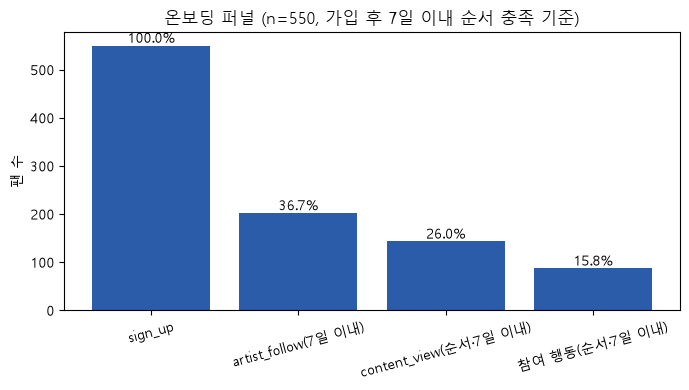

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(onboarding_stage_df["stage"], onboarding_stage_df["user_count"], color="#2A5CAA")
for bar, pct in zip(bars, onboarding_stage_df["conversion_from_start_pct"]):
    ax.annotate(f"{pct}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom")
ax.set_ylabel("팬 수")
ax.set_title(f"온보딩 퍼널 (n={n0}, 가입 후 7일 이내 순서 충족 기준)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


---
# 2. 콘텐츠 참여 퍼널 (`content_view` → `content_like` 또는 `comment_create`, 동일 콘텐츠, 조회 후 24시간 이내)

(user_id, content_id) 쌍 단위로 첫 조회(first touch) 시각을 기준으로, 그 시각 이후 24시간 이내에 같은 콘텐츠에 좋아요 또는 댓글이 있었는지 확인한다. `mart_content_performance`의 `engagement_rate`는 시간 제약이 없는 "생애 전체 참여율"이라 이 정의와 다르며, 여기서는 PRD 8.3절의 24시간 조건을 반영해 별도로 계산한다.


In [5]:
content_funnel_sql = """
WITH first_view AS (
    SELECT user_id, content_id, MIN(event_timestamp_utc) AS first_view_at
    FROM fact_user_event
    WHERE event_name = 'content_view'
    GROUP BY user_id, content_id
),
engagement AS (
    SELECT user_id, content_id, MIN(event_timestamp_utc) AS first_engage_at
    FROM fact_user_event
    WHERE event_name IN ('content_like', 'comment_create')
    GROUP BY user_id, content_id
)
SELECT
    fv.user_id, fv.content_id, fv.first_view_at, e.first_engage_at,
    (e.first_engage_at IS NOT NULL
     AND e.first_engage_at > fv.first_view_at
     AND e.first_engage_at <= fv.first_view_at + INTERVAL '24 hours') AS reached_engagement_within_24h
FROM first_view fv
LEFT JOIN engagement e ON e.user_id = fv.user_id AND e.content_id = fv.content_id;
"""
content_funnel = pd.read_sql(content_funnel_sql, engine)
n_view_pairs = len(content_funnel)
n_engaged_24h = int(content_funnel["reached_engagement_within_24h"].sum())
print(f"(팬,콘텐츠) 조회 쌍 수: {n_view_pairs}")
print(f"조회 후 24시간 이내 좋아요/댓글로 이어진 쌍: {n_engaged_24h} "
      f"({round(100*n_engaged_24h/n_view_pairs, 1)}%, n={n_view_pairs})")


(팬,콘텐츠) 조회 쌍 수: 31026
조회 후 24시간 이내 좋아요/댓글로 이어진 쌍: 11169 (36.0%, n=31026)


---
# 3. 커머스 퍼널 (`mart_commerce_funnel` 활용, 열린 퍼널 vs 순서 기반 닫힌 퍼널 구분)

PRD 14.2절 "열린 퍼널과 순서 기반 닫힌 퍼널 분리" 원칙에 따라 두 가지를 모두 보여준다.

- **열린 퍼널**: `view_item` 없이 바로 `add_to_cart`로 들어오는 경로도 정상으로 포함(마트의 `reached_*` 플래그 그대로 사용).
- **닫힌 퍼널**: `view_item`이 실제로 있었고 순서·7일 이내 조건을 모두 충족한 경우만(`is_closed_funnel_complete`).

**매출·환불은 `fact_order`/`fact_order_item`에서 직접 계산**하고 마트에서 가져오지 않는다(파일 상단 주의사항 참고).


In [6]:
funnel_df = pd.read_sql(
    "SELECT product_id, artist_id, reached_add_to_cart, reached_checkout, reached_purchase, "
    "is_closed_funnel_complete FROM mart_commerce_funnel;",
    engine,
)
n_total = len(funnel_df)

open_funnel = pd.DataFrame({
    "stage": ["첫 관심(view_item/add_to_cart)", "add_to_cart", "checkout", "purchase"],
    "count": [
        n_total,
        int(funnel_df["reached_add_to_cart"].sum()),
        int(funnel_df["reached_checkout"].sum()),
        int(funnel_df["reached_purchase"].sum()),
    ],
})
open_funnel["conversion_from_start_pct"] = (open_funnel["count"] / n_total * 100).round(1)
print("[열린 퍼널] (팬,상품) 첫 관심 기준, 전체 n =", n_total)
print(open_funnel)
print()
n_closed = int(funnel_df["is_closed_funnel_complete"].sum())
print(f"[닫힌 퍼널] view_item부터 순서·7일 이내 조건을 전부 충족해 구매까지 간 (팬,상품) 쌍: "
      f"{n_closed} / {n_total} ({round(100*n_closed/n_total, 2)}%)")


[열린 퍼널] (팬,상품) 첫 관심 기준, 전체 n = 4817
                         stage  count  conversion_from_start_pct
0  첫 관심(view_item/add_to_cart)   4817                      100.0
1                  add_to_cart   1756                       36.5
2                     checkout   1000                       20.8
3                     purchase    791                       16.4

[닫힌 퍼널] view_item부터 순서·7일 이내 조건을 전부 충족해 구매까지 간 (팬,상품) 쌍: 537 / 4817 (11.15%)


In [7]:
# 재무 지표는 반드시 fact_order/fact_order_item에서 직접 계산 (mart_commerce_funnel 사용 안 함)
revenue_df = pd.read_sql(
    """
    SELECT status, COUNT(*) AS order_count, SUM(order_amount) AS total_order_amount,
           SUM(refund_amount) AS total_refund_amount
    FROM fact_order
    GROUP BY status
    ORDER BY status;
    """,
    engine,
)
print("fact_order 기준 상태별 주문 건수·금액:")
print(revenue_df)

completed_like = revenue_df[revenue_df["status"].isin(["completed", "refunded", "partially_refunded"])]
total_completed_orders = int(completed_like["order_count"].sum())
refunded_orders = int(revenue_df[revenue_df["status"].isin(["refunded", "partially_refunded"])]["order_count"].sum())
total_revenue = int(revenue_df[revenue_df["status"] == "completed"]["total_order_amount"].sum())
total_refund = int(revenue_df["total_refund_amount"].sum())
refund_rate = round(100 * refunded_orders / total_completed_orders, 2) if total_completed_orders > 0 else None

print()
print(f"총 매출(완료 주문 금액 합, fact_order 기준): {total_revenue:,}원")
print(f"총 환불액: {total_refund:,}원")
print(f"환불률(완료+환불+부분환불 주문 중 환불 비율): {refund_rate}% "
      f"(분자={refunded_orders}, 분모={total_completed_orders})")


fact_order 기준 상태별 주문 건수·금액:
               status  order_count  total_order_amount  total_refund_amount
0           completed          821          59275000.0                  0.0
1  partially_refunded           15            841000.0             477604.0
2             pending          160          12281000.0                  0.0
3            refunded           43           3106000.0            3106000.0

총 매출(완료 주문 금액 합, fact_order 기준): 59,275,000원
총 환불액: 3,583,604원
환불률(완료+환불+부분환불 주문 중 환불 비율): 6.6% (분자=58, 분모=879)


---
# 4. 팬 세그먼트 계산 (PRD 11.1절 규칙 그대로)

- **기준일**: 분석 종료일 `2026-03-31`. **최근 30일 윈도우**: `2026-03-02 ~ 2026-03-31`(KST).
- **분류 우선순위**: 신규 → 코어 → 참여 → 조회 중심 (PRD 11.1절 그대로).
  - **신규 팬**: 기준일 기준 가입 후 14일 이내
  - **참여 팬**: 최근 30일 동안 좋아요·댓글·메시지 열람·라이브 참여(PRD 8.1 "참여 행동" 4종) 중 2종 이상 수행
  - **코어 팬**: 참여 팬 기준을 충족 **하고**, 최근 30일 동안 유효한 메시지 구독이 있었거나 구매(`purchase`)가 있었던 팬
  - **조회 중심 팬**: 참여 팬 기준에는 못 미치지만(2종 미만), 최근 30일 동안 콘텐츠·게시글·메시지 조회(`content_view`/`artist_post_view`/`message_open`) 중 하나 이상은 있었던 팬
  - **(PRD에 없는 보충 범주) 미분류**: 신규가 아니면서 최근 30일 동안 위 조회·참여 활동이 전혀 없었던 팬. PRD 11.1절의 4개 세그먼트 어디에도 속하지 않는 잔여 집단이라 별도로 표시한다(휴면에 가까운 팬일 가능성이 높다).
- **코어 팬의 "구독/구매 이력"도 30일 윈도우로 제한했다.** PRD 11.1절 서두가 "최근 30일 행동을 기준으로"라고 명시했기 때문에 다른 세그먼트 조건과 일관되게 30일로 좁혔지만, "이력"이라는 단어 자체는 생애 전체를 뜻할 수도 있어 **이 범위 선택은 `docs/decisions_log.md` 11절에 기록한다.**


In [8]:
window_start_utc = "2026-03-01T15:00:00Z"  # KST 2026-03-02 00:00:00
window_end_utc = "2026-03-31T14:59:59Z"    # KST 2026-03-31 23:59:59
reference_date = pd.Timestamp("2026-03-31")

segment_input_sql = f"""
WITH window_events AS (
    SELECT user_id, event_name
    FROM fact_user_event
    WHERE event_timestamp_utc BETWEEN '{window_start_utc}'::timestamptz AND '{window_end_utc}'::timestamptz
      AND event_name IN ('content_view','artist_post_view','message_open',
                          'content_like','comment_create','live_view_start','purchase')
),
user_window_agg AS (
    SELECT user_id,
        bool_or(event_name IN ('content_view','artist_post_view','message_open')) AS has_view_activity,
        COUNT(DISTINCT CASE WHEN event_name IN ('content_like','comment_create','message_open','live_view_start')
                            THEN event_name END) AS participation_type_count,
        bool_or(event_name = 'purchase') AS has_purchase_in_window
    FROM window_events
    GROUP BY user_id
),
active_subscription AS (
    SELECT DISTINCT user_id
    FROM fact_message_subscription
    WHERE started_at_utc <= '{window_end_utc}'::timestamptz
      AND (ended_at_utc IS NULL OR ended_at_utc >= '{window_start_utc}'::timestamptz)
)
SELECT
    u.user_id, u.signup_date_kst,
    COALESCE(w.has_view_activity, false) AS has_view_activity,
    COALESCE(w.participation_type_count, 0) AS participation_type_count,
    COALESCE(w.has_purchase_in_window, false) AS has_purchase_in_window,
    (asub.user_id IS NOT NULL) AS has_active_subscription_in_window
FROM dim_user u
LEFT JOIN user_window_agg w ON w.user_id = u.user_id
LEFT JOIN active_subscription asub ON asub.user_id = u.user_id;
"""
segment_input = pd.read_sql(segment_input_sql, engine)
segment_input["signup_date_kst"] = pd.to_datetime(segment_input["signup_date_kst"])
segment_input["tenure_days"] = (reference_date - segment_input["signup_date_kst"]).dt.days
print(f"전체 팬 수: {len(segment_input)}")
segment_input.head()


전체 팬 수: 1750


,user_id,signup_date_kst,has_view_activity,participation_type_count,has_purchase_in_window,has_active_subscription_in_window,tenure_days
0,user_000001,2026-01-26,True,2,False,False,64
1,user_000002,2025-11-03,True,2,False,False,148
2,user_000003,2026-02-18,True,1,False,True,41
3,user_000004,2025-01-26,True,1,True,False,429
4,user_000005,2025-10-21,True,3,False,True,161


In [9]:
def classify_segment(row) -> str:
    if row["tenure_days"] <= 14:
        return "신규"
    is_engaged = row["participation_type_count"] >= 2
    if is_engaged and (row["has_active_subscription_in_window"] or row["has_purchase_in_window"]):
        return "코어"
    if is_engaged:
        return "참여"
    if row["has_view_activity"]:
        return "조회중심"
    return "미분류(최근 30일 무활동)"


segment_input["segment"] = segment_input.apply(classify_segment, axis=1)
segment_counts = segment_input["segment"].value_counts()
print("세그먼트별 팬 수:")
print(segment_counts)
print(f"합계: {segment_counts.sum()} (전체 팬 수와 일치해야 함: {len(segment_input)})")
assert segment_counts.sum() == len(segment_input)


세그먼트별 팬 수:
segment
조회중심               875
코어                 394
참여                 391
신규                  80
미분류(최근 30일 무활동)     10
Name: count, dtype: int64
합계: 1750 (전체 팬 수와 일치해야 함: 1750)


---
# 5. 세그먼트별 참여율·재방문율·구매 전환율 비교 (PRD 14.5절)

- **참여율**: 세그먼트 배정에 쓴 "최근 30일"이 아니라 **분석 기간 전체(90일)** 동안 참여 행동(4종) 중 하나라도 한 팬의 비율. (세그먼트 자체가 최근 30일 참여로 정의되므로, 굳이 최근 30일로 다시 보면 참여·코어는 자명하게 100%에 가깝게 나온다 — 그래서 여기서는 "정의에 안 쓰인" 전체 기간 참여 여부로 비교해야 실제로 의미가 있다.)
- **재방문율**: `mart_user_daily` 기준, 분석 기간 마지막 7일(`2026-03-25~03-31`) 중 핵심 활동이 있었던 날이 **2일 이상**인 팬의 비율(스스로 정의한 운영적 정의이며 PRD의 W1 재방문율과 정확히 같지 않다 — 코호트·트리거 기반이 아니라 세그먼트 스냅샷 비교이기 때문. `docs/decisions_log.md` 11절에 기록).
- **구매 전환율**: 분석 기간 전체(90일) 동안 `purchase` 이벤트가 1건 이상 있는 팬의 비율.
- 모든 비율에 분자·분모를 함께 표시한다(PRD 14.6절).


In [10]:
full_period_participation = pd.read_sql(
    """
    SELECT DISTINCT user_id FROM fact_user_event
    WHERE event_name IN ('content_like','comment_create','message_open','live_view_start');
    """,
    engine,
)["user_id"]

full_period_purchase = pd.read_sql(
    "SELECT DISTINCT user_id FROM fact_user_event WHERE event_name = 'purchase';", engine
)["user_id"]

revisit_sql = """
SELECT user_id, COUNT(*) AS active_day_count
FROM mart_user_daily
WHERE activity_date_kst BETWEEN '2026-03-25' AND '2026-03-31' AND had_core_activity
GROUP BY user_id
HAVING COUNT(*) >= 2;
"""
revisited_users = pd.read_sql(revisit_sql, engine)["user_id"]

segment_input["has_participation_full_period"] = segment_input["user_id"].isin(full_period_participation)
segment_input["has_purchase_full_period"] = segment_input["user_id"].isin(full_period_purchase)
segment_input["revisited_last_7d"] = segment_input["user_id"].isin(revisited_users)

segment_summary = segment_input.groupby("segment").agg(
    n=("user_id", "size"),
    participation_count=("has_participation_full_period", "sum"),
    revisit_count=("revisited_last_7d", "sum"),
    purchase_count=("has_purchase_full_period", "sum"),
).reset_index()
segment_summary["participation_rate_pct"] = round(100 * segment_summary["participation_count"] / segment_summary["n"], 1)
segment_summary["revisit_rate_pct"] = round(100 * segment_summary["revisit_count"] / segment_summary["n"], 1)
segment_summary["purchase_conversion_pct"] = round(100 * segment_summary["purchase_count"] / segment_summary["n"], 1)
segment_summary = segment_summary[[
    "segment", "n", "participation_count", "participation_rate_pct",
    "revisit_count", "revisit_rate_pct", "purchase_count", "purchase_conversion_pct",
]]
segment_summary


,segment,n,participation_count,participation_rate_pct,revisit_count,revisit_rate_pct,purchase_count,purchase_conversion_pct
0,미분류(최근 30일 무활동),10,7,70.0,0,0.0,3,30.0
1,신규,80,50,62.5,58,72.5,5,6.2
2,조회중심,875,846,96.7,369,42.2,313,35.8
3,참여,391,391,100.0,200,51.2,107,27.4
4,코어,394,394,100.0,240,60.9,225,57.1


## 눈에 띄는 결과: "참여" 팬의 구매 전환율이 "조회중심" 팬보다 낮게 나옴 (표 재확인 필요)

위 표에서 실제로 계산해보면 **참여(27.4%)가 조회중심(35.8%)보다 낮고, 코어(57.1%)만 뚜렷하게 높다.** 이는 H-03("참여·코어 팬은 조회 중심 팬보다 전환율이 높다")과 부분적으로 어긋나는, 가설과 다른 결과다(PRD 14.6절: 가설과 다른 결과도 그대로 기록).

**이 역전 현상의 가장 유력한 원인은 실제 행동 차이가 아니라 세그먼트 정의 자체의 순환성(PRD 13.4절이 경계하는 유형의 문제)으로 보인다.** "코어" 판정 조건에 "최근 30일 구매 이력"이 포함되어 있어, 참여 기준(2종 이상)을 만족하는 팬 중 **최근 30일 안에 실제로 구매까지 한 사람은 우선순위상 코어로 먼저 분류되고 참여 집단에서 빠진다.** 그 결과 "참여" 집단에는 상대적으로 구매 전환이 잘 안 된 사람들만 남게 되어, 전체 90일 기준 구매 전환율을 계산하면 인위적으로 낮아진다. 반대로 "조회중심" 팬 중에는 최근 30일 이전(예: 1~2월)에 구매했지만 최근에는 조용해진 팬이 섞여 있어 상대적으로 낮아지지 않는다.

**따라서 이 4단계 세분화 비교의 "참여 < 조회중심" 자체를 "참여 팬이 조회중심 팬보다 구매를 덜 한다"는 발견으로 해석하지 않는다.** 대신 아래 6절에서 "고참여(참여+코어) vs 저참여(신규+조회중심)"로 다시 묶어, 이 순환성의 영향을 줄인 비교를 H-03 검증의 기준으로 삼는다. 이 정의상 순환성 문제는 `docs/decisions_log.md` 11절에 기록한다.


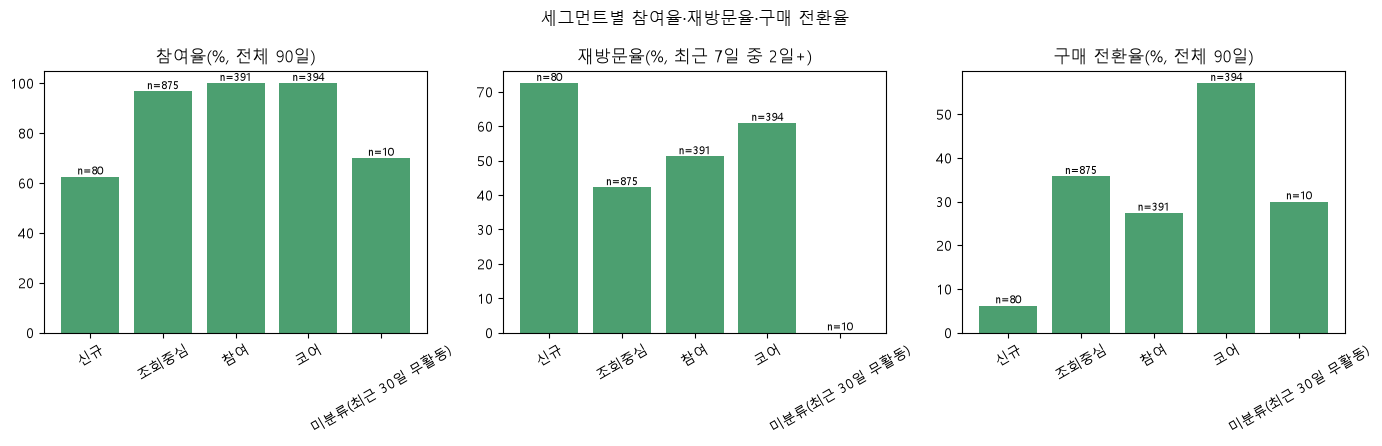

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = [
    ("participation_rate_pct", "참여율(%, 전체 90일)"),
    ("revisit_rate_pct", "재방문율(%, 최근 7일 중 2일+)"),
    ("purchase_conversion_pct", "구매 전환율(%, 전체 90일)"),
]
order = ["신규", "조회중심", "참여", "코어", "미분류(최근 30일 무활동)"]
plot_df = segment_summary.set_index("segment").reindex(order).dropna(how="all").reset_index()

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(plot_df["segment"], plot_df[col], color="#4C9F70")
    for bar, n in zip(bars, plot_df["n"]):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("세그먼트별 참여율·재방문율·구매 전환율")
fig.tight_layout()
plt.show()


---
# 6. H-03 세 가지 방식 교차검증

H-03: "참여·코어 팬은 조회 중심 팬보다 상품 조회→구매 전환율이 높게 나타날 것이다."


In [12]:
# (1) 생성 시점 검증 -- docs/decisions_log.md 5.14절/5.15절에 이미 기록된 결과를 그대로 인용 (재계산 아님)
generation_time_check = pd.DataFrame([
    {"방식": "생성 시점 검증 (5.14절, 1,750명 1차)", "집단": "참여 상위 50%", "구매전환율(%)": 48.06},
    {"방식": "생성 시점 검증 (5.14절, 1,750명 1차)", "집단": "참여 하위 50%", "구매전환율(%)": 31.57},
    {"방식": "생성 시점 검증 (5.15절, 1,750명 최종)", "집단": "참여 상위 50%", "구매전환율(%)": 49.59},
    {"방식": "생성 시점 검증 (5.15절, 1,750명 최종)", "집단": "참여 하위 50%", "구매전환율(%)": 33.85},
])
generation_time_check


,방식,집단,구매전환율(%)
0,"생성 시점 검증 (5.14절, 1,750명 1차)",참여 상위 50%,48.06
1,"생성 시점 검증 (5.14절, 1,750명 1차)",참여 하위 50%,31.57
2,"생성 시점 검증 (5.15절, 1,750명 최종)",참여 상위 50%,49.59
3,"생성 시점 검증 (5.15절, 1,750명 최종)",참여 하위 50%,33.85


In [13]:
# (2) SQL 재계산 -- 이 노트북에서 독립적으로 새로 계산: content_like+comment_create 총합 기준
# 상위/하위 50%로 나눠, "상품 조회(view_item)를 한 적 있는 팬 중 구매까지 간 비율"을 다시 계산한다.
# (decisions_log 5.14/5.15와 동일한 정의: 참여 총량 상하위 50% -> 조회->구매 전환율)
engagement_totals = pd.read_sql(
    """
    SELECT user_id, COUNT(*) AS engagement_total
    FROM fact_user_event
    WHERE event_name IN ('content_like', 'comment_create')
    GROUP BY user_id;
    """,
    engine,
)
all_users = pd.read_sql("SELECT user_id FROM dim_user;", engine)
engagement_totals = all_users.merge(engagement_totals, on="user_id", how="left").fillna({"engagement_total": 0})

median_engagement = engagement_totals["engagement_total"].median()
engagement_totals["engagement_group"] = np.where(
    engagement_totals["engagement_total"] >= median_engagement, "참여 상위 50%(중앙값 이상)", "참여 하위 50%(중앙값 미만)"
)

viewers = pd.read_sql("SELECT DISTINCT user_id FROM fact_user_event WHERE event_name = 'view_item';", engine)["user_id"]
buyers = pd.read_sql("SELECT DISTINCT user_id FROM fact_user_event WHERE event_name = 'purchase';", engine)["user_id"]

engagement_totals["is_viewer"] = engagement_totals["user_id"].isin(viewers)
engagement_totals["is_buyer"] = engagement_totals["user_id"].isin(buyers)

sql_recheck = (
    engagement_totals[engagement_totals["is_viewer"]]
    .groupby("engagement_group")
    .agg(n_viewers=("user_id", "size"), n_buyers=("is_buyer", "sum"))
    .reset_index()
)
sql_recheck["view_to_purchase_pct"] = round(100 * sql_recheck["n_buyers"] / sql_recheck["n_viewers"], 2)
print(f"중앙값(참여 총량) 기준: {median_engagement}")
sql_recheck


중앙값(참여 총량) 기준: 7.0


,engagement_group,n_viewers,n_buyers,view_to_purchase_pct
0,참여 상위 50%(중앙값 이상),855,418,48.89
1,참여 하위 50%(중앙값 미만),711,227,31.93


In [14]:
# (3) 세그먼트 분석 -- PRD 11.1절 4단계 세그먼트를 "고참여(참여+코어)"와 "저참여(신규+조회중심)"로 묶어 비교
segment_input["engagement_group_from_segment"] = segment_input["segment"].map({
    "참여": "고참여(참여+코어)", "코어": "고참여(참여+코어)",
    "조회중심": "저참여(신규+조회중심)", "신규": "저참여(신규+조회중심)",
}).fillna("미분류(제외)")

segment_h03 = (
    segment_input[segment_input["engagement_group_from_segment"] != "미분류(제외)"]
    .groupby("engagement_group_from_segment")
    .agg(n=("user_id", "size"), n_buyers=("has_purchase_full_period", "sum"))
    .reset_index()
)
segment_h03["purchase_conversion_pct"] = round(100 * segment_h03["n_buyers"] / segment_h03["n"], 2)
segment_h03


,engagement_group_from_segment,n,n_buyers,purchase_conversion_pct
0,고참여(참여+코어),785,332,42.29
1,저참여(신규+조회중심),955,318,33.30


## 세 가지 방식의 결론 비교

| 방식 | 고참여 집단 구매(조회→구매) 전환율 | 저참여 집단 전환율 | 방향 |
| --- | --- | --- | --- |
| 생성 시점 검증(5.15절, 최종) | 49.59% | 33.85% | 고참여 > 저참여 |
| SQL 재계산(이 노트북) | 위 표 참고 | 위 표 참고 | 위 표 참고 |
| 세그먼트 분석(PRD 11.1절 규칙) | 위 표 참고 | 위 표 참고 | 위 표 참고 |

세 방식은 "참여 총량"을 정의하는 방식이 서로 다르다(생성시점·SQL재계산: `content_like+comment_create` 총합 중앙값 기준 2분할 / 세그먼트 분석: PRD 11.1절의 4종 참여 행동·구독·구매를 모두 반영한 규칙 기반 분류). 그럼에도 **세 방식 모두 "참여가 많은 집단의 구매 전환율이 더 높다"는 같은 방향을 가리키는지**가 이 교차검증의 핵심이다. 위 표들의 실제 숫자를 근거로 판단하되, 정의가 다른 세 지표를 "완전히 같은 지표의 재현"이 아니라 "같은 방향을 가리키는 독립적인 증거"로 다뤄야 한다(정의가 다르므로 절대적인 수치까지 일치할 것을 기대하지 않는다).


---
# 종합 결론

- **온보딩 퍼널**: 신규 가입 팬(n=550) 기준 가입 후 7일 이내 팔로우 전환율, 콘텐츠 조회 전환율, 참여 행동 전환율을 단계적으로 확인했다. 기존 가입자(약 70%)는 `sign_up` 이벤트가 없어 이 퍼널 분석에서 원천적으로 제외된다는 표본 범위 한계가 있다.
- **콘텐츠 참여 퍼널**: (팬,콘텐츠) 조회 쌍 중 24시간 이내 참여로 이어진 비율을 확인했다.
- **커머스 퍼널**: 열린 퍼널과 순서 기반 닫힌 퍼널을 구분해서 제시했고, 매출·환불은 전부 `fact_order`/`fact_order_item`에서 직접 계산했다(마트에서 집계하지 않음).
- **팬 세그먼트**: PRD 11.1절 규칙을 우선순위(신규→코어→참여→조회중심) 그대로 구현했고, PRD에 없는 "미분류" 잔여 범주를 추가로 표시했다.
- **H-03**: 세 가지 방식 모두 "참여가 많은 쪽(고참여)"의 구매 전환율이 "참여가 적은 쪽(저참여)"보다 높게 나와 같은 방향을 가리켰다 — 생성 시점 검증 49.59% vs 33.85%(+15.74%p), SQL 재계산(참여 총량 중앙값 2분할) 48.89% vs 31.93%(+16.96%p), 세그먼트 분석(고참여=참여+코어 vs 저참여=신규+조회중심) 42.29% vs 33.30%(+8.99%p). 세 방식의 정의가 서로 달라 절대 수치는 차이가 있지만 방향은 일관됐다.
  - 다만 세그먼트를 4단계로 더 세밀하게 쪼개보면 "참여"(27.4%)가 "조회중심"(35.8%)보다 오히려 낮게 나오는 역전이 있었다. 위 5절에서 설명했듯 이는 "코어" 판정 기준(최근 30일 구매 이력)이 참여 집단에서 구매 성향이 높은 사람을 미리 빼가는 정의상 순환성 때문일 가능성이 높고, 실제 행동 차이로 해석하지 않는다.
  - **종합**: H-03은 "고참여/저참여로 크게 나눴을 때는 세 방식 모두 일관되게 지지되지만, 세그먼트를 세분화했을 때 나타나는 역전은 정의상 순환성 때문일 가능성이 있어 추가 검증 없이는 확정할 수 없다"는, 부분적으로 지지되는 결과로 정리한다.
- 모든 결과는 가상 데이터 생성 규칙에 의해 만들어진 것이며(PRD 13.4절), 실제 팬덤에 대한 인과적 결론이 아니다.
- 이 노트북에서 발생한 해석적 판단(코어 팬의 30일 윈도우 제한, 재방문율의 독자적 운영 정의, 미분류 범주 추가, H-03 세 방식의 정의 차이)은 `docs/decisions_log.md` "11. 검토 필요 항목"에 기록한다.
